In [1]:
## 1. Leitura da base de dados
import pandas as pd

df = pd.read_csv("../dados/trafego.csv")
alvo = "Visualizações" # Mude aqui se decidir focar em Sessões depois
df.head()

,Data,Sessões,Usuários ativos,Visualizações
0,1 de jul. de 2023,3109,2047,5566
1,2 de jul. de 2023,3099,2083,5498
2,3 de jul. de 2023,24119,13516,46786
3,4 de jul. de 2023,23635,13335,44984
4,5 de jul. de 2023,22217,13014,43559


In [2]:
## 2. Verificação da estrutura dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Data             1020 non-null   str  
 1   Sessões          1020 non-null   int64
 2   Usuários ativos  1020 non-null   int64
 3   Visualizações    1020 non-null   int64
dtypes: int64(3), str(1)
memory usage: 32.0 KB


## 3. Conversão da coluna de data

A coluna `Data` foi inicialmente carregada como texto (`str`), e não como data reconhecida pelo Python. Por isso, foi necessário realizar algumas conversões antes de utilizá-la na análise.

Primeiro, os nomes abreviados dos meses em português, como `jul.` e `ago.`, foram substituídos por seus respectivos números (`07`, `08` etc.). Essa etapa foi necessária porque a função de conversão de datas utilizada no pandas trabalha mais facilmente com valores numéricos padronizados no formato dia/mês/ano.

Em seguida, a expressão textual `" de "` foi substituída pelo caractere `/`, transformando datas como `1 de jul. de 2023` em um padrão mais adequado para conversão, como `1/07/2023`.

Por fim, a coluna foi convertida para o tipo `datetime`, que é o formato apropriado para trabalhar com datas no pandas. Essa conversão é importante porque permite extrair variáveis temporais úteis ao modelo, como dia da semana, mês, fim de semana e outras características calendáricas que podem influenciar o comportamento do tráfego.


In [3]:
meses = {
    "jan.": "01", "fev.": "02", "mar.": "03", "abr.": "04",
    "mai.": "05", "jun.": "06", "jul.": "07", "ago.": "08",
    "set.": "09", "out.": "10", "nov.": "11", "dez.": "12"
}

for mes_pt, mes_num in meses.items():
    df["Data"] = df["Data"].str.replace(mes_pt, mes_num, regex=False)

df["Data"] = df["Data"].str.replace(" de ", "/", regex=False)
df["Data"] = pd.to_datetime(df["Data"], format="%d/%m/%Y")

df.head()
df = df.sort_values('Data').reset_index(drop=True)

## 4. Criação da variável dia da semana

Nesta etapa, é criada uma variável representando o dia da semana de cada observação. Essa informação pode ser relevante para o modelo, pois o tráfego do portal apresenta comportamento distinto entre dias úteis e finais de semana.

In [4]:
df["dia_semana"] = df["Data"].dt.dayofweek + 1
df[["Data", "dia_semana"]].head(10)

,Data,dia_semana
0,2023-07-01,6
1,2023-07-02,7
2,2023-07-03,1
3,2023-07-04,2
4,2023-07-05,3
5,2023-07-06,4
6,2023-07-07,5
7,2023-07-08,6
8,2023-07-09,7
9,2023-07-10,1


## 5. Criação da variável indicadora de fim de semana

Além do dia da semana, foi criada uma variável binária para identificar se a observação pertence a um fim de semana. Essa variável pode ser útil porque o tráfego do portal tende a cair significativamente aos sábados e domingos.

In [5]:
df["fim_de_semana"] = (df["Data"].dt.dayofweek >= 5).astype(int)
df[["Data", "dia_semana", "fim_de_semana"]].head(10)

,Data,dia_semana,fim_de_semana
0,2023-07-01,6,1
1,2023-07-02,7,1
2,2023-07-03,1,0
3,2023-07-04,2,0
4,2023-07-05,3,0
5,2023-07-06,4,0
6,2023-07-07,5,0
7,2023-07-08,6,1
8,2023-07-09,7,1
9,2023-07-10,1,0


## 6. Criação da variável mês

Também foi criada uma variável correspondente ao mês de cada observação. Essa informação pode ajudar o modelo a captar padrões sazonais mais amplos no comportamento do tráfego ao longo do ano.

In [6]:
df["mes"] = df["Data"].dt.month
df[["Data", "mes"]].head(90)

,Data,mes
0,2023-07-01,7
1,2023-07-02,7
2,2023-07-03,7
3,2023-07-04,7
4,2023-07-05,7
...,...,...
85,2023-09-24,9
86,2023-09-25,9
87,2023-09-26,9
88,2023-09-27,9


## 7. Criação da variável de recesso judiciário

Foi criada uma variável binária para identificar o período de recesso judiciário, compreendido entre 20 de dezembro e 6 de janeiro. Essa variável foi incluída porque esse intervalo tende a alterar de forma relevante o padrão de utilização do portal.

In [7]:
df["recesso_judiciario"] = (
    ((df["Data"].dt.month == 12) & (df["Data"].dt.day >= 20)) |
    ((df["Data"].dt.month == 1) & (df["Data"].dt.day <= 6))
).astype(int)



## 8. Criação de variáveis relacionadas a feriados nacionais e feriados móveis

Nesta etapa, foram criadas variáveis indicadoras para representar datas com potencial impacto no tráfego do Portal. Foram considerados tanto os feriados nacionais de data fixa quanto feriados móveis relevantes para o funcionamento do Judiciário, como Carnaval, quarta-feira de cinzas, sexta-feira da Paixão e Corpus Christi.

A inclusão dessas variáveis é importante porque tais datas podem provocar reduções abruptas no volume de acessos, em razão da suspensão de expediente, da diminuição da atividade institucional ou da alteração do comportamento dos usuários. Dessa forma, busca-se fornecer aos modelos informações temporais adicionais que permitam explicar melhor oscilações atípicas da série.

In [8]:
from dateutil.easter import easter
import pandas as pd

# =========================================
# 9.1 Feriados nacionais de data fixa
# =========================================

feriados_fixos = [
    (1, 1),    # Confraternização Universal
    (4, 21),   # Tiradentes
    (5, 1),    # Dia do Trabalho
    (9, 7),    # Independência do Brasil
    (10, 12),  # Nossa Senhora Aparecida
    (11, 2),   # Finados
    (11, 15),  # Proclamação da República
    (12, 25)   # Natal
]

datas_feriados_fixos = []

ano_inicial = df['Data'].dt.year.min()
ano_final = df['Data'].dt.year.max()

for ano in range(ano_inicial, ano_final + 1):
    for mes, dia in feriados_fixos:
        datas_feriados_fixos.append(pd.Timestamp(year=ano, month=mes, day=dia))

    # Consciência Negra: feriado nacional a partir de 2024
    if ano >= 2024:
        datas_feriados_fixos.append(pd.Timestamp(year=ano, month=11, day=20))

feriados_nacionais_fixos = pd.DatetimeIndex(datas_feriados_fixos)

feriados_nacionais_fixos = feriados_nacionais_fixos[
    (feriados_nacionais_fixos >= df['Data'].min()) &
    (feriados_nacionais_fixos <= df['Data'].max())
]

df['feriado_nacional_fixo'] = (
    df['Data'].isin(feriados_nacionais_fixos) & 
    (df['fim_de_semana'] == 0)
).astype(int)

# =========================================
# 9.2 Feriados móveis relevantes
# =========================================

datas_carnaval = []
datas_quarta_cinzas = []
datas_sexta_paixao = []
datas_corpus_christi = []

for ano in range(ano_inicial, ano_final + 1):
    pascoa = pd.Timestamp(easter(ano))

    carnaval_segunda = pascoa - pd.Timedelta(days=48)
    carnaval_terca = pascoa - pd.Timedelta(days=47)
    quarta_cinzas = pascoa - pd.Timedelta(days=46)
    sexta_paixao = pascoa - pd.Timedelta(days=2)
    corpus_christi = pascoa + pd.Timedelta(days=60)

    datas_carnaval.extend([carnaval_segunda, carnaval_terca])
    datas_quarta_cinzas.append(quarta_cinzas)
    datas_sexta_paixao.append(sexta_paixao)
    datas_corpus_christi.append(corpus_christi)

df['carnaval'] = (df['Data'].isin(pd.DatetimeIndex(datas_carnaval)) & (df['fim_de_semana'] == 0)).astype(int)
df['quarta_cinzas'] = (df['Data'].isin(pd.DatetimeIndex(datas_quarta_cinzas)) & (df['fim_de_semana'] == 0)).astype(int)
df['sexta_paixao'] = (df['Data'].isin(pd.DatetimeIndex(datas_sexta_paixao)) & (df['fim_de_semana'] == 0)).astype(int)
df['corpus_christi'] = (df['Data'].isin(pd.DatetimeIndex(datas_corpus_christi)) & (df['fim_de_semana'] == 0)).astype(int)

# =========================================
# Visualização rápida
# =========================================

df.loc[
    (df['feriado_nacional_fixo'] == 1) |
    (df['carnaval'] == 1) |
    (df['quarta_cinzas'] == 1) |
    (df['sexta_paixao'] == 1) |
    (df['corpus_christi'] == 1),
    ['Data', 'feriado_nacional_fixo', 'carnaval', 'quarta_cinzas', 'sexta_paixao', 'corpus_christi']
].sort_values('Data')

,Data,feriado_nacional_fixo,carnaval,quarta_cinzas,sexta_paixao,corpus_christi
68,2023-09-07,1,0,0,0,0
103,2023-10-12,1,0,0,0,0
124,2023-11-02,1,0,0,0,0
137,2023-11-15,1,0,0,0,0
177,2023-12-25,1,0,0,0,0
184,2024-01-01,1,0,0,0,0
226,2024-02-12,0,1,0,0,0
227,2024-02-13,0,1,0,0,0
228,2024-02-14,0,0,1,0,0
272,2024-03-29,0,0,0,1,0


In [9]:
df.loc[df["feriado_nacional_fixo"] == 1, "Data"].dt.year.value_counts().sort_index()

Data
2023    5
2024    5
2025    5
2026    1
Name: count, dtype: int64

## 09. Criação da variável de datas fixas relevantes ao Judiciário

Além dos feriados nacionais de data fixa, foi criada uma variável binária para identificar datas fixas relevantes ao Poder Judiciário e à administração pública. Essas datas podem influenciar o padrão de acesso ao portal e, por isso, foram tratadas separadamente dos feriados nacionais.

Optou-se por não incluir o dia 20 de novembro nessa variável, pois essa data já foi considerada na variável de feriado nacional fixo a partir de 2024.


In [10]:
datas_judiciario = [
    (8, 11),   # Dia do Magistrado
    (10, 28),  # Dia do Servidor Público
    (12, 8)    # Dia da Justiça
]

datas_especificas = []

ano_inicial = df["Data"].dt.year.min()
ano_final = df["Data"].dt.year.max()

for ano in range(ano_inicial, ano_final + 1):
    for mes, dia in datas_judiciario:
        datas_especificas.append(pd.Timestamp(year=ano, month=mes, day=dia))

datas_judiciario_fixas = pd.DatetimeIndex(datas_especificas)

datas_judiciario_fixas = datas_judiciario_fixas[
    (datas_judiciario_fixas >= df["Data"].min()) &
    (datas_judiciario_fixas <= df["Data"].max())
]

df["data_especifica_judiciario"] = (
    df["Data"].isin(datas_judiciario_fixas) & 
    (df['fim_de_semana'] == 0)
).astype(int)

df.loc[df["data_especifica_judiciario"] == 1, ["Data", "data_especifica_judiciario"]]

,Data,data_especifica_judiciario
41,2023-08-11,1
160,2023-12-08,1
485,2024-10-28,1
772,2025-08-11,1
850,2025-10-28,1
891,2025-12-08,1


## 10. Criação da variável de ponto facultativo por emenda

Foi criada uma variável binária para identificar pontos facultativos decorrentes da prática de emenda de feriados. Considerou-se que, quando um feriado nacional fixo ocorre em uma terça-feira, a segunda-feira imediatamente anterior também tende a apresentar alteração relevante no funcionamento institucional e no padrão de uso do portal. De forma análoga, quando o feriado ocorre em uma quinta-feira, a sexta-feira imediatamente posterior também passa a ser tratada como data de emenda.

Essa variável foi mantida separada da variável de feriado, a fim de distinguir o efeito do feriado propriamente dito do efeito da suspensão de atividades por emenda.

In [11]:
datas_emenda = []

for data in feriados_nacionais_fixos:
    dia_semana = data.dayofweek  # segunda=0 ... domingo=6

    if dia_semana == 1:  # terça-feira
        datas_emenda.append(data - pd.Timedelta(days=1))

    elif dia_semana == 3:  # quinta-feira
        datas_emenda.append(data + pd.Timedelta(days=1))
for data_cc in datas_corpus_christi:
    datas_emenda.append(data_cc + pd.Timedelta(days=1))
# --------------------------

pontos_facultativos_emenda = pd.DatetimeIndex(datas_emenda)

pontos_facultativos_emenda = pontos_facultativos_emenda[
    (pontos_facultativos_emenda >= df["Data"].min()) &
    (pontos_facultativos_emenda <= df["Data"].max())
]

df["ponto_facultativo_emenda"] = df["Data"].isin(pontos_facultativos_emenda).astype(int)

df.loc[df["ponto_facultativo_emenda"] == 1, ["Data", "ponto_facultativo_emenda"]]

,Data,ponto_facultativo_emenda
69,2023-09-08,1
104,2023-10-13,1
125,2023-11-03,1
335,2024-05-31,1
671,2025-05-02,1
720,2025-06-20,1
874,2025-11-21,1
909,2025-12-26,1
916,2026-01-02,1


## 11. Verifica se alguns valores estão faltando

Nesta etapa, foi realizada a verificação de valores ausentes em todas as colunas da base de dados.

A análise mostrou que **não há valores ausentes no dataset**, o que indica que, nesse aspecto, a base está íntegra para as próximas etapas de tratamento e modelagem.

In [12]:
print('=== VALORES AUSENTES POR COLUNA ===')

missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Valores_Nulos': missing,
    'Percentual (%)': missing_pct.round(2)
})

missing_df = missing_df[missing_df['Valores_Nulos'] > 0].sort_values(
    by='Valores_Nulos',
    ascending=False
)

if len(missing_df) > 0:
    print(missing_df)
else:
    print('✓ Não há valores ausentes no dataset!')

=== VALORES AUSENTES POR COLUNA ===
✓ Não há valores ausentes no dataset!


##12. Verificação de duplicatas

Nesta etapa, foi realizada a verificação de registros duplicados na base de dados, com o objetivo de identificar possíveis repetições que pudessem comprometer a consistência da análise.

In [13]:
print("=== VERIFICAÇÃO DE DUPLICATAS ===")

duplicadas_total = df.duplicated().sum()
duplicadas_data = df.duplicated(subset=['Data']).sum()

print(f"Linhas totalmente duplicadas: {duplicadas_total}")
print(f"Datas duplicadas: {duplicadas_data}")

=== VERIFICAÇÃO DE DUPLICATAS ===
Linhas totalmente duplicadas: 0
Datas duplicadas: 0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Data                        1020 non-null   datetime64[us]
 1   Sessões                     1020 non-null   int64         
 2   Usuários ativos             1020 non-null   int64         
 3   Visualizações               1020 non-null   int64         
 4   dia_semana                  1020 non-null   int32         
 5   fim_de_semana               1020 non-null   int64         
 6   mes                         1020 non-null   int32         
 7   recesso_judiciario          1020 non-null   int64         
 8   feriado_nacional_fixo       1020 non-null   int64         
 9   carnaval                    1020 non-null   int64         
 10  quarta_cinzas               1020 non-null   int64         
 11  sexta_paixao                1020 non-null   int64         
 12  cor

13- Verificação de Outliers

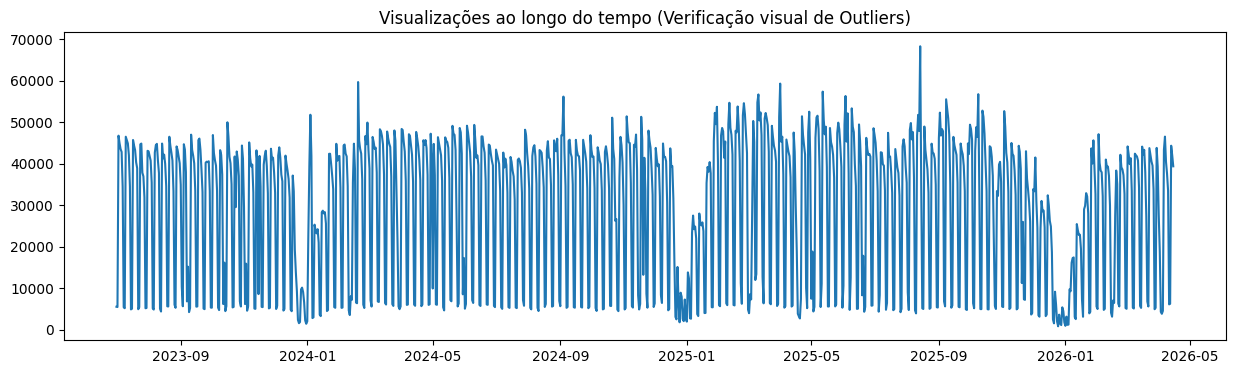

Média de Visualizações: 28890.42
Mediana de Visualizações: 37129.50
--- 5 Dias de MAIOR tráfego (Visualizações) ---
          Data  Visualizações  dia_semana
775 2025-08-14          68325           4
233 2024-02-19          59710           1
640 2025-04-01          59333           2
681 2025-05-12          57402           1
831 2025-10-09          56784           4

--- 5 Dias de MENOR tráfego (Visualizações) ---
          Data  Visualizações  dia_semana
908 2025-12-25            865           4
915 2026-01-01            972           4
911 2025-12-28           1154           7
917 2026-01-03           1207           6
918 2026-01-04           1281           7
Desvio padrão de Visualizações: 17721.75


In [15]:
# %%
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(df['Data'], df[alvo])
plt.title(f'{alvo} ao longo do tempo (Verificação visual de Outliers)')
plt.show()

media = df[alvo].mean()
mediana = df[alvo].median()

print(f"Média de {alvo}: {media:.2f}")
print(f"Mediana de {alvo}: {mediana:.2f}")

print(f"--- 5 Dias de MAIOR tráfego ({alvo}) ---")
print(df.nlargest(5, alvo)[['Data', alvo, 'dia_semana']])

print(f"\n--- 5 Dias de MENOR tráfego ({alvo}) ---")
print(df.nsmallest(5, alvo)[['Data', alvo, 'dia_semana']])
desvio_padrao = df[alvo].std()
print(f"Desvio padrão de {alvo}: {desvio_padrao:.2f}")

14- Estatísticas Descritivas Completas

In [16]:
colunas_trafego = ['Sessões', 'Usuários ativos', 'Visualizações']

dispersao = pd.DataFrame({
    'Média': df[colunas_trafego].mean(),
    'Mediana': df[colunas_trafego].median(),
    'Range': df[colunas_trafego].max() - df[colunas_trafego].min(),
    'Desvio_Padrão': df[colunas_trafego].std(),
    'Q1 (25%)': df[colunas_trafego].quantile(0.25),
    'Q3 (75%)': df[colunas_trafego].quantile(0.75),
    'IQR': df[colunas_trafego].quantile(0.75) - df[colunas_trafego].quantile(0.25),
    'CV (%)': (df[colunas_trafego].std() / df[colunas_trafego].mean()) * 100 
})

print('\n=== MEDIDAS DE DISPERSÃO (Tráfego) ===')
print(dispersao.round(2))


=== MEDIDAS DE DISPERSÃO (Tráfego) ===
                    Média  Mediana  Range  Desvio_Padrão  Q1 (25%)  Q3 (75%)  \
Sessões          16249.81  21061.5  31359        9681.94   3791.25  24512.00   
Usuários ativos   9139.00  11712.0  21129        5277.56   2469.00  13584.25   
Visualizações    28890.42  37129.5  67460       17721.75   6105.00  43408.25   

                      IQR  CV (%)  
Sessões          20720.75   59.58  
Usuários ativos  11115.25   57.75  
Visualizações    37303.25   61.34  


15 Histogramas e Box Plots

C:\Users\DIOGO\AppData\Local\Temp\ipykernel_2044\466033375.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fim_de_semana', y=alvo, data=df, ax=axes[1], palette='Set2')
C:\Users\DIOGO\AppData\Local\Temp\ipykernel_2044\466033375.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Dia Útil', 'Fim de Semana'])


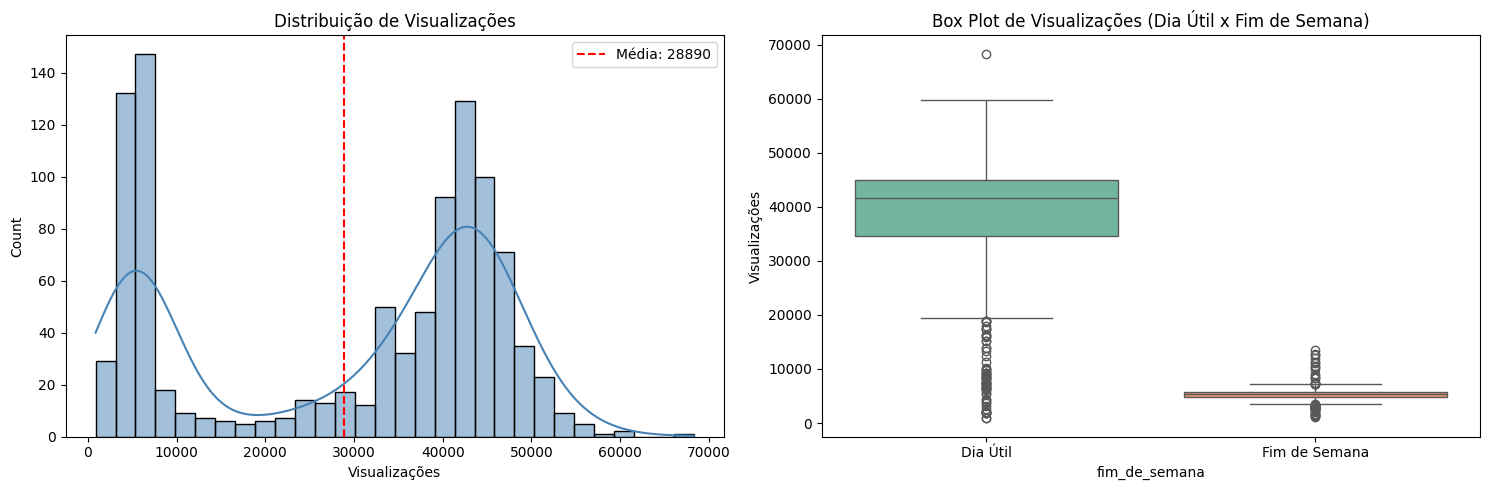

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df[alvo], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribuição de {alvo}')
axes[0].axvline(df[alvo].mean(), color='red', linestyle='--', label=f'Média: {df[alvo].mean():.0f}')
axes[0].legend()

# Box Plot cruzando fim de semana (Muito importante para o seu contexto)
sns.boxplot(x='fim_de_semana', y=alvo, data=df, ax=axes[1], palette='Set2')
axes[1].set_title(f'Box Plot de {alvo} (Dia Útil x Fim de Semana)')
axes[1].set_xticklabels(['Dia Útil', 'Fim de Semana'])

plt.tight_layout()
plt.show()

16- Matriz de correlação

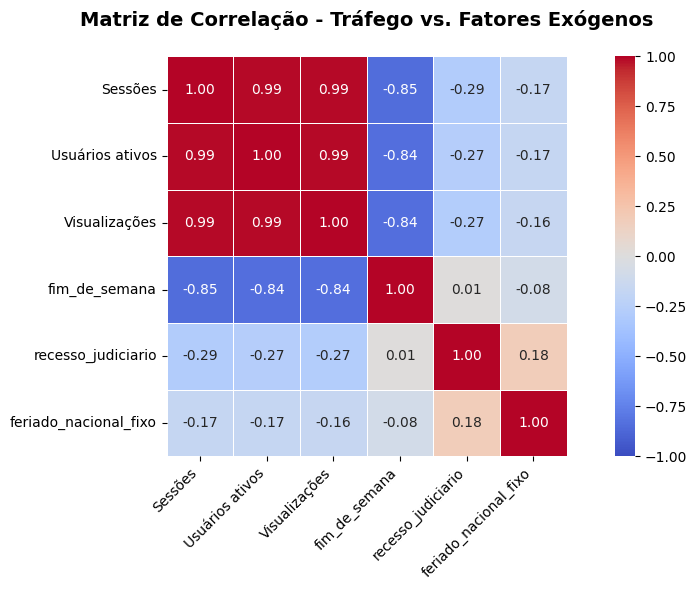

In [18]:
cols_correlacao = [
    'Sessões', 'Usuários ativos', 'Visualizações', 
    'fim_de_semana', 'recesso_judiciario', 'feriado_nacional_fixo'
]

correlacao = df[cols_correlacao].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlação - Tráfego vs. Fatores Exógenos\n', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

17- Teste de Normalidade de Shapiro-Wilk

In [19]:
from scipy import stats

print('=== TESTE DE NORMALIDADE (Shapiro-Wilk) ===')
statistic, p_value = stats.shapiro(df[alvo])
resultado = 'Normal' if p_value > 0.05 else 'Não Normal (Assimétrica)'

print(f'Variável: {alvo}')
print(f'Estatística: {statistic:.4f}')
print(f'p-valor: {p_value:.4e}')
print(f'Resultado: A distribuição é {resultado}')

=== TESTE DE NORMALIDADE (Shapiro-Wilk) ===
Variável: Visualizações
Estatística: 0.8356
p-valor: 3.7789e-31
Resultado: A distribuição é Não Normal (Assimétrica)


18- Gera a planilha final tratada 

In [20]:
df.to_csv("../dados/trafego_tratado.csv", index=False)

19 - Gera a base específica de modelagem para prever visualizações com os lags e médias móveis para SVR, árvores de decisão e redes neurais. Foram criados 3 lags (1, 7 e 30 dias antes). Além disso foram criadas duas médias móveis defasadas (7 e 30 dias), para capturar tendências semanais e mensais.

In [21]:
df_modelagem_visualizacoes = df.copy()

# Mantém apenas a variável-alvo e os fatores explicativos úteis
colunas_modelagem = [
    "Data",
    "Visualizações",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_modelagem_visualizacoes = df_modelagem_visualizacoes[colunas_modelagem].copy()

# Lags da própria variável-alvo
df_modelagem_visualizacoes["vis_lag_1"] = df_modelagem_visualizacoes["Visualizações"].shift(1)
df_modelagem_visualizacoes["vis_lag_7"] = df_modelagem_visualizacoes["Visualizações"].shift(7)
df_modelagem_visualizacoes["vis_lag_30"] = df_modelagem_visualizacoes["Visualizações"].shift(30)

# Médias móveis da própria variável-alvo
# shift(1) evita usar informação do próprio dia
df_modelagem_visualizacoes["vis_mm_7"] = (
    df_modelagem_visualizacoes["Visualizações"].shift(1).rolling(window=7).mean()
)
df_modelagem_visualizacoes["vis_mm_30"] = (
    df_modelagem_visualizacoes["Visualizações"].shift(1).rolling(window=30).mean()
)

# Remove linhas iniciais que ficam com NaN por causa dos lags/médias móveis
df_modelagem_visualizacoes = df_modelagem_visualizacoes.dropna().reset_index(drop=True)

# Salva o arquivo final de modelagem
df_modelagem_visualizacoes.to_csv(
    "../dados/trafego_modelagem_visualizacoes.csv",
    index=False
)

print("Arquivo salvo com sucesso: ../dados/trafego_modelagem_visualizacoes.csv")
print(df_modelagem_visualizacoes.head())
print(df_modelagem_visualizacoes.info())

Arquivo salvo com sucesso: ../dados/trafego_modelagem_visualizacoes.csv
        Data  Visualizações  dia_semana  fim_de_semana  mes  \
0 2023-07-31          43139           1              0    7   
1 2023-08-01          43013           2              0    8   
2 2023-08-02          41899           3              0    8   
3 2023-08-03          40761           4              0    8   
4 2023-08-04          35460           5              0    8   

   recesso_judiciario  feriado_nacional_fixo  carnaval  quarta_cinzas  \
0                   0                      0         0              0   
1                   0                      0         0              0   
2                   0                      0         0              0   
3                   0                      0         0              0   
4                   0                      0         0              0   

   sexta_paixao  corpus_christi  data_especifica_judiciario  \
0             0               0                

20 - Gera a base específica para o Prophet (sem lags, sessões e usuários)

In [23]:
df_prophet_base = df.copy()

# Mantém apenas a variável-alvo e os regressores conhecidos no futuro
colunas_prophet = [
    "Data",
    "Visualizações",
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_prophet_base = df_prophet_base[colunas_prophet].copy()

# Renomeia para o padrão exigido pelo Prophet
df_prophet_base = df_prophet_base.rename(columns={
    "Data": "ds",
    "Visualizações": "y"
})

# Garante ordenação por data
df_prophet_base = df_prophet_base.sort_values("ds").reset_index(drop=True)

# Salva o arquivo final para Prophet
df_prophet_base.to_csv("../dados/trafego_prophet_visualizacoes.csv", index=False)

print("Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv")
print(df_prophet_base.head())
print(df_prophet_base.info())

Arquivo salvo com sucesso: ../dados/trafego_prophet_visualizacoes.csv
          ds      y  fim_de_semana  recesso_judiciario  feriado_nacional_fixo  \
0 2023-07-01   5566              1                   0                      0   
1 2023-07-02   5498              1                   0                      0   
2 2023-07-03  46786              0                   0                      0   
3 2023-07-04  44984              0                   0                      0   
4 2023-07-05  43559              0                   0                      0   

   carnaval  quarta_cinzas  sexta_paixao  corpus_christi  \
0         0              0             0               0   
1         0              0             0               0   
2         0              0             0               0   
3         0              0             0               0   
4         0              0             0               0   

   data_especifica_judiciario  ponto_facultativo_emenda  
0                       